# 9주차: 자연어 처리(NLP) 기초 실습

본 실습에서는 자연어 처리의 첫 단계인 **텍스트 전처리(Text Preprocessing)**와 한국어/영어 **토큰화(Tokenization)** 및 **형태소 분석(Morphological Analysis)**을 다룹니다.

## 1. 환경 설정 및 필수 라이브러리 임포트

한국어 형태소 분석을 위해 `KoNLPy`를 활용하고, 전처리를 위해 `re`(정규표현식)와 `nltk` 등을 임포트합니다.

In [1]:
import re
import numpy as np
import pandas as pd
import konlpy
from konlpy.tag import Okt, Kkma, Mecab
from kiwipiepy import Kiwi
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from config import CONTENT_DIR
from collections import Counter
import matplotlib.pyplot as plt
import platform
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis
import pyLDAvis.lda_model  # pyLDAvis 3.4.0 이상 최신 버전용
# (참고: 만약 ModuleNotFoundError가 발생하면 아래 구문으로 변경해 주세요)
# import pyLDAvis.sklearn as lda_model

# 한글 폰트 설정 (Mac/Linux/Windows 호환)
if platform.system() == 'Darwin': # macOS
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows': # Windows
    plt.rc('font', family='Malgun Gothic')
else: # Linux (Ubuntu 등)
    plt.rc('font', family='NanumGothic')

print("KoNLPy version:", konlpy.__version__)
print("NLTK version:", nltk.__version__)

KoNLPy version: 0.6.0
NLTK version: 3.9.4


## 2. 텍스트 정규화 (Text Normalization)

정규표현식을 사용하여 이메일, 특수문자, 문장부호 등 분석에 방해가 되는 요소를 제거합니다.

In [2]:
raw_text = "안녕하세요!!! NLP 실습에 오신 것을 환영합니다. 이메일 주소는 test@example.com 입니다. 1234567890 ^오^"

# 한글, 영문, 공백을 제외한 문자 제거
cleaned_text = re.sub(r'[^a-zA-Z가-힣\s]', '', raw_text)
print("Original:", raw_text)
print("Cleaned:", cleaned_text)

Original: 안녕하세요!!! NLP 실습에 오신 것을 환영합니다. 이메일 주소는 test@example.com 입니다. 1234567890 ^오^
Cleaned: 안녕하세요 NLP 실습에 오신 것을 환영합니다 이메일 주소는 testexamplecom 입니다  오


## 3. 한국어 형태소 분석 및 토큰화 (KoNLPy)

KoNLPy에서 제공하는 대표적인 분석기(`Okt`, `Kkma`, `Hannanum`)들의 특성을 비교해 봅니다.

In [3]:

okt = Okt()
kkma = Kkma()
mecab = Mecab()
kiwi = Kiwi()

def clean_text(text):
    text = re.sub(r'[^ㄱ-ㅎㅏ-ㅣ가-힣\s]', '', text)
    text = text.lower()         # 소문자 변환
    return text

def getResult(sample_sentence, tList=[okt,kkma,mecab,kiwi]):
    for tokenizer in tList:
        name = tokenizer.__class__.__name__
        print(f"\n[{name} Morphological Analysis]")
        
        # KoNLPy 계열 분석기 처리
        if name in ['Okt', 'Kkma', 'Mecab']:
            print("Morphs:", tokenizer.morphs(sample_sentence))
            print("Nouns:", tokenizer.nouns(sample_sentence))
            print("Pos:", tokenizer.pos(sample_sentence))
            
        # Kiwi 분석기 처리 (인터페이스 변환)
        elif name == 'Kiwi':
            tokens = tokenizer.tokenize(sample_sentence)
            # 형태소 추출
            print("Morphs:", [t.form for t in tokens])
            # 명사 추출 (체언 계열 태그 필터링: NNG, NNP, NP 등 N으로 시작하는 태그)
            print("Nouns:", [t.form for t in tokens if t.tag.startswith('N')])
            # 품사 태깅 추출
            print("Pos:", [(t.form, t.tag) for t in tokens])

sample_sentence = "아버지가방에들어가신다."
getResult(sample_sentence)


[Okt Morphological Analysis]
Morphs: ['아버지', '가방', '에', '들어가신다', '.']
Nouns: ['아버지', '가방']
Pos: [('아버지', 'Noun'), ('가방', 'Noun'), ('에', 'Josa'), ('들어가신다', 'Verb'), ('.', 'Punctuation')]

[Kkma Morphological Analysis]
Morphs: ['아버지', '가방', '에', '들어가', '시', 'ㄴ다', '.']
Nouns: ['아버지', '아버지가방', '가방']
Pos: [('아버지', 'NNG'), ('가방', 'NNG'), ('에', 'JKM'), ('들어가', 'VV'), ('시', 'EPH'), ('ㄴ다', 'EFN'), ('.', 'SF')]

[Mecab Morphological Analysis]
Morphs: ['아버지', '가', '방', '에', '들어가', '신다', '.']
Nouns: ['아버지', '방']
Pos: [('아버지', 'NNG'), ('가', 'JKS'), ('방', 'NNG'), ('에', 'JKB'), ('들어가', 'VV'), ('신다', 'EP+EF'), ('.', 'SF')]

[Kiwi Morphological Analysis]
Morphs: ['아버지', '가', '방', '에', '들어가', '시', 'ᆫ다', '.']
Nouns: ['아버지', '방']
Pos: [('아버지', 'NNG'), ('가', 'JKS'), ('방', 'NNG'), ('에', 'JKB'), ('들어가', 'VV'), ('시', 'EP'), ('ᆫ다', 'EF'), ('.', 'SF')]


## 데이터 정제

In [4]:
# 예제 데이터
reviews = [
    "이 영화 정말 재미있었어요! 강력 추천합니다. 👍",
    "완전 지루하고 시간 낭비였습니다. 😡",
    "연기는 훌륭했지만, 스토리는 조금 아쉬웠어요. 🤔",
    "명작입니다. 꼭 보세요! 👏",
    "별로였습니다. 기대보다 실망이 컸어요. 😞",
    '친구들과 함께하면 더욱 재미있어요!',
    '그래픽이 아주 멋집니다. 추천해요!',
    '초반에는 재미있는데, 시간이 지나면 지루해집니다.',
]
cleaned_reviews = [clean_text(review) for review in reviews]

for text in cleaned_reviews:
    getResult(text, [mecab])


[Mecab Morphological Analysis]
Morphs: ['이', '영화', '정말', '재미있', '었', '어요', '강력', '추천', '합니다']
Nouns: ['영화', '강력', '추천']
Pos: [('이', 'MM'), ('영화', 'NNG'), ('정말', 'MAG'), ('재미있', 'VA'), ('었', 'EP'), ('어요', 'EF'), ('강력', 'NNG'), ('추천', 'NNG'), ('합니다', 'XSV+EC')]

[Mecab Morphological Analysis]
Morphs: ['완전', '지루', '하', '고', '시간', '낭비', '였', '습니다']
Nouns: ['시간', '낭비']
Pos: [('완전', 'MAG'), ('지루', 'XR'), ('하', 'XSA'), ('고', 'EC'), ('시간', 'NNG'), ('낭비', 'NNG'), ('였', 'VCP+EP'), ('습니다', 'EF')]

[Mecab Morphological Analysis]
Morphs: ['연기', '는', '훌륭', '했', '지만', '스토리', '는', '조금', '아쉬웠', '어요']
Nouns: ['연기', '스토리']
Pos: [('연기', 'NNG'), ('는', 'JX'), ('훌륭', 'XR'), ('했', 'XSA+EP'), ('지만', 'EC'), ('스토리', 'NNG'), ('는', 'JX'), ('조금', 'MAG'), ('아쉬웠', 'VV+EP'), ('어요', 'EF')]

[Mecab Morphological Analysis]
Morphs: ['명작', '입니다', '꼭', '보', '세요']
Nouns: ['명작']
Pos: [('명작', 'NNG'), ('입니다', 'VCP+EF'), ('꼭', 'MAG'), ('보', 'VV'), ('세요', 'EP+EF')]

[Mecab Morphological Analysis]
Morphs: ['별로', '였', '습니다', '기대',

In [5]:
# 1. 한국어 불용어 사전 정의 (List가 아닌 Set으로 정의하여 조회 시간복잡도 O(1) 보장)
stopwords_set = {
    '영화', '진짜', '정말', '완전', '그냥', '별로', '시간', '초반', 
    '조금', '아주', '더욱', '꼭', '대체', '다소', '다소간'
}
# 2. 불용어 정제 파이프라인 함수
def clean_and_tokenize(text, tokenizer, stop_words):
    # Mecab 형태소 및 품사 추출
    pos_tagged = tokenizer.pos(text)
    
    cleaned_tokens = []
    for word, tag in pos_tagged:
        # Mecab의 복합 태그(예: XSA+EC) 대응을 위해 메인 태그만 추출
        main_tag = tag.split('+')[0]
        
        # [품사 필터링] 조사(J), 어미(E), 기호(S), 접미사(XS) 제거
        if (main_tag.startswith('J') or 
            main_tag.startswith('E') or 
            main_tag.startswith('S') or 
            main_tag.startswith('XS')):
            continue
            
        # [단어 매칭 필터링] 불용어 사전에 들어있지 않은 토큰만 수집
        if word not in stop_words:
            cleaned_tokens.append(word)
            
    return cleaned_tokens
# 3. 테스트 실행
print("=== 불용어 정제 테스트 ===")
for text in cleaned_reviews:
    result = clean_and_tokenize(text, mecab, stopwords_set)
    print(f"원문: {text}")
    print(f"정제: {result}")
    print("-" * 40)

=== 불용어 정제 테스트 ===
원문: 이 영화 정말 재미있었어요 강력 추천합니다 
정제: ['이', '재미있', '강력', '추천']
----------------------------------------
원문: 완전 지루하고 시간 낭비였습니다 
정제: ['지루', '낭비', '였']
----------------------------------------
원문: 연기는 훌륭했지만 스토리는 조금 아쉬웠어요 
정제: ['연기', '훌륭', '스토리', '아쉬웠']
----------------------------------------
원문: 명작입니다 꼭 보세요 
정제: ['명작', '입니다', '보']
----------------------------------------
원문: 별로였습니다 기대보다 실망이 컸어요 
정제: ['였', '기대', '실망', '컸']
----------------------------------------
원문: 친구들과 함께하면 더욱 재미있어요
정제: ['친구', '함께', '하', '재미있']
----------------------------------------
원문: 그래픽이 아주 멋집니다 추천해요
정제: ['그래픽', '멋', '집니다', '추천']
----------------------------------------
원문: 초반에는 재미있는데 시간이 지나면 지루해집니다
정제: ['재미있', '지나', '지루']
----------------------------------------


In [6]:
# 1. 불용어 사전 (동사/형용사의 원형 기준 등록 가능)
stopwords_set = {'영화', '진짜', '정말', '완전', '그냥', '별로', '시간', '초반', '조금', '아주', '더욱', '꼭', '이', '하'}

# 2. 화이트리스트 + 형태소 원형 추출 함수 (Kiwi 활용)
def clean_with_kiwi(text, tokenizer, stop_words):
    tokens = tokenizer.tokenize(text)
    
    cleaned_tokens = []
    # 분석에 의미 있는 품사만 정의 (명사 계열, 동사, 형용사 어간)
    allowed_tags = {'NNG', 'NNP', 'NNB', 'NP', 'VV', 'VA', 'XR'}
    
    for token in tokens:
        # 1. 허용된 품사 태그만 수집
        if token.tag in allowed_tags:
            # 2. 불용어 사전에 포함되지 않은 단어만 추출 (원형 token.form 사용)
            if token.form not in stop_words:
                cleaned_tokens.append(token.form)
                
    return cleaned_tokens

# 3. 테스트 실행
print("=== Kiwi 기반 화이트리스트 정제 테스트 ===")
for text in cleaned_reviews:
    result = clean_with_kiwi(text, kiwi, stopwords_set)
    print(f"원문: {text}")
    print(f"정제: {result}")
    print("-" * 40)


=== Kiwi 기반 화이트리스트 정제 테스트 ===
원문: 이 영화 정말 재미있었어요 강력 추천합니다 
정제: ['재미있', '강력', '추천']
----------------------------------------
원문: 완전 지루하고 시간 낭비였습니다 
정제: ['지루', '낭비']
----------------------------------------
원문: 연기는 훌륭했지만 스토리는 조금 아쉬웠어요 
정제: ['연기', '훌륭', '스토리']
----------------------------------------
원문: 명작입니다 꼭 보세요 
정제: ['명작', '보']
----------------------------------------
원문: 별로였습니다 기대보다 실망이 컸어요 
정제: ['기대', '실망', '크']
----------------------------------------
원문: 친구들과 함께하면 더욱 재미있어요
정제: ['친구', '재미있']
----------------------------------------
원문: 그래픽이 아주 멋집니다 추천해요
정제: ['그래픽', '멋지', '추천']
----------------------------------------
원문: 초반에는 재미있는데 시간이 지나면 지루해집니다
정제: ['재미', '있', '지나', '지루']
----------------------------------------


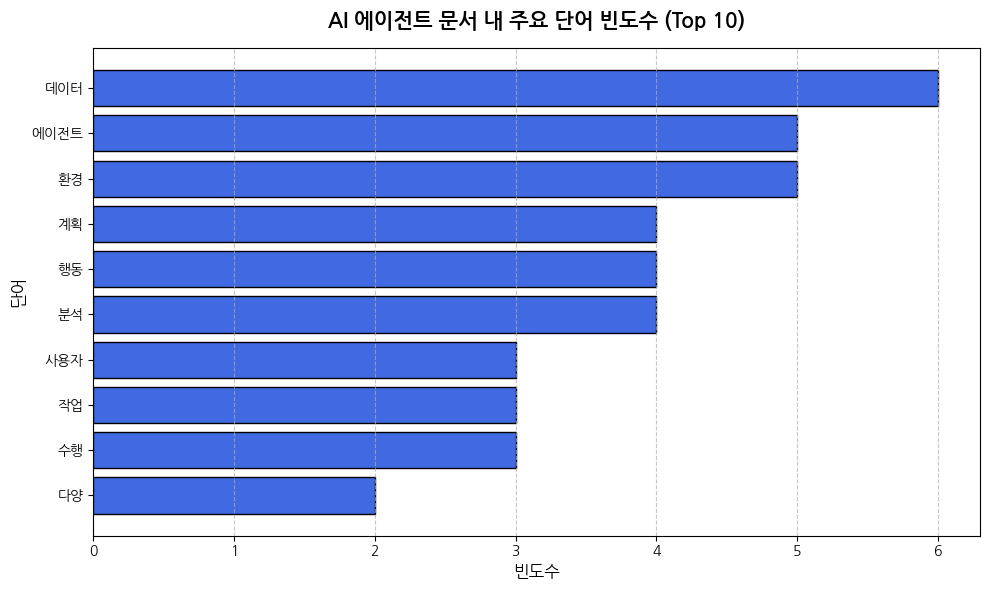

In [7]:
document = '''
AI 에이전트는 사용자의 요구에 맞게 다양한 작업을 자동으로 수행하고 지원하는 인공지능 (AI) 시스템으로, 개인의 일정 관리,정보 검색과 제공, 통신 기능, 스마트홈 관리, 언어 번역과 대화 등의 다양한 기능을 수행한다. 예컨대 AI 에이전트는 스스로 마우스 커서를 움직여 텍스트를 입력하고, 이메일을 보내거나 쇼핑하는 등 사람을 대신해 복잡한 컴퓨터 작업을 수행한다. 이는 특정 목표를 달성하기 위해 스스로 계획을 수립하고 실행하는 추론과 행동이 가능하다는 점에서 단순한 AI 챗봇 수준을 넘어선 것이다.

AI 에이전트는 크게 3단계로 작동하는데, 우선 센서를 통해 환경의 상태를 감지하거나 데이터를 수집하는 것이 첫 번째이다. 이후 입력 데이터를 분석하고 이를 바탕으로 목표 달성을 위한 최적의 행동을 계획하는 생각(Think)을 거쳐, 계획된 행동(Act)을 실행하여 환경에 영향을 미치게 된다. 이처럼 사용자가 명령을 내리면 AI 에이전트는 자연어 처리 능력을 기반으로 맥락을 이해하고 정확하고 검증된 결과를 제공한다. 예컨대 자율주행차의 경우 환경 데이터를 분석해 최적의 경로를 선태하고 장애물과 충돌을 피하는 역할을 하며, 스마트홈에서는 사용자의 행동에 따라 에어컨·조명 등의 각종 가전제품을 자동으로 조절한다. 또 금융 분야에서는 금융사기 탐지와 각 개인에 맞는 투자를 추천하며, 의료 분야에서는 환자의 데이터를 분석해 질병 진단 및 치료계획을 지원하는 역할을 한다. 

이처럼 AI 에이전트는 반복적이고 시간이 많이 드는 작업을 효율적으로 처리할 수 있고, 환경 변화에 빠르게 대응할 수 있으며, 데이터를 분석해 사람보다 정확한 의사 결정을 내릴 수 있다는 장점이 있다. 반면 품질 높은 데이터가 없으면 성능이 저하되고, 편향된 학습의 위험이 있으며, 예측 불가능한 환경에서는 성능이 제한될 수 있다는 단점이 있다. 
'''

# 1. 텍스트 전처리 (특수문자 및 기호 제거)
cleaned_doc = clean_text(document)
# 2. 토큰화 및 불용어 정제 (이전에 만든 Kiwi 기반 함수 사용)
tokens = clean_with_kiwi(cleaned_doc, kiwi, stopwords_set)
# [실무 팁] 의미 파악을 위해 글자 수가 2글자 이상인 단어만 필터링
# '보', '크', '하' 같은 1글자 용언 어간/명사가 지표를 흐리는 것을 방지합니다.
refined_tokens = [word for word in tokens if len(word) >= 2]
# 3. Counter를 이용한 빈도수 집계
word_counts = Counter(refined_tokens)
# 4. 상위 10개 단어 추출
top_10_words = word_counts.most_common(10)
# 5. 판다스 데이터프레임으로 변환하여 시각화 및 분석
df_frequency = pd.DataFrame(top_10_words, columns=['단어', '빈도수'])

# 가로 바 차트 그리기
plt.figure(figsize=(10, 6))
plt.barh(df_frequency['단어'][::-1], df_frequency['빈도수'][::-1], color='royalblue', edgecolor='black')
plt.title('AI 에이전트 문서 내 주요 단어 빈도수 (Top 10)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('빈도수', fontsize=12)
plt.ylabel('단어', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [8]:
df = pd.read_csv(CONTENT_DIR / '배달의민족댓글.csv')
df = df.dropna()
df = df.reset_index()
df.drop(['index','Unnamed: 0'], axis=1, inplace=True)

# 1. TfidfVectorizer에 주입할 커스텀 토크나이저 함수 정의
# (clean_text 전처리 + Kiwi 형태소/원형 추출 + 불용어 제거 + 2글자 이상 필터링 일괄 처리)
def korean_tokenizer(text):
    cleaned = clean_text(text)
    tokens = clean_with_kiwi(cleaned, kiwi, stopwords_set)
    return [word for word in tokens if len(word) >= 2]
# 2. TF-IDF 벡터라이저 인스턴스 생성
# 커스텀 토크나이저 지정 및 한글 경고 방지를 위해 token_pattern=None 설정
tfidf_vectorizer = TfidfVectorizer(tokenizer=korean_tokenizer, token_pattern=None, min_df=1)
# 3. 배민 댓글 상위 5개 샘플에 대해 TF-IDF 계산 수행
sample_comments = df['댓글'].head(5).tolist()
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_comments)
# 4. 단어 사전(Vocabulary) 추출 및 매핑
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
# 5. 각 리뷰(문서)별 TF-IDF 가중치 상위 3개 단어 추출 및 출력
print("=== 리뷰별 TF-IDF 기반 핵심 키워드 추출 결과 ===\n")
for idx, doc in enumerate(sample_comments):
    print(f"[{idx+1}번 리뷰 원문]")
    print(doc)
    
    # 해당 문서의 TF-IDF 벡터 값 추출
    tf_idf_vector = tfidf_matrix[idx].toarray().flatten()
    
    # TF-IDF 점수가 높은 순으로 정렬하여 상위 3개 단어의 인덱스 추출
    top_indices = tf_idf_vector.argsort()[::-1][:3]
    
    # 0점이 아닌 의미 있는 단어만 필터링하여 출력
    top_keywords = []
    for i in top_indices:
        if tf_idf_vector[i] > 0:
            top_keywords.append(f"{feature_names[i]}({tf_idf_vector[i]:.3f})")
            
    print(f"👉 핵심 키워드 (TF-IDF 가중치): {', '.join(top_keywords)}")
    print("-" * 60)

=== 리뷰별 TF-IDF 기반 핵심 키워드 추출 결과 ===

[1번 리뷰 원문]
80분 걸린다길래 주문취소 하려고 주문내역에 들어가면 계속 최신 정보를 불러오지 못했다고만 로딩반복. 로딩 이미지는 깨져서 나오고 안정적인 네트워크 상황 하에서 새로고침을 눌러도 무한로딩이고 심지어 지금 진행중인 주문내역 정보조차 정확하지 않음. 코로나 때문에 서버가 불안정한건지 뭔지는 모르겠으나 결국엔 취소 못하고 꼼짝없이 기다려 먹게됐네요.
👉 핵심 키워드 (TF-IDF 가중치): 주문(0.356), 로딩(0.294), 안정(0.294)
------------------------------------------------------------
[2번 리뷰 원문]
음식 하나 시키는데 우리나라 앱들은 1) 국내 번호 필요함. 번호 인증 필수 2) 카드 결제선택시 또 다른 은행앱을 깔고 인증을 한 3번정도 더 해야함... 해외카드로 결제수단은 아예없고 왜 현금결제 옵션도 없나요... 음식하나 시켜먹는데 이렇게 복잡한 나라 우리나라 밖에없습니다 IT강국은 무슨... 왜 핸드폰 번호 인증, 카드인증등 불편하게 스탭이 많나요 앱 사용중에도 UI/UX, front-end 쪽으로도 다 너무 짜증나고 결국 저녁도 못시켜먹음 하... 외국거주자는 방법이 없네요 왜 해외카드는 결제가 안되나요....
👉 핵심 키워드 (TF-IDF 가중치): 인증(0.402), 카드(0.402), 결제(0.324)
------------------------------------------------------------
[3번 리뷰 원문]
왜이렇게 업데이트 할때마다 사용하기 점점 불편하게 바뀌는지? 클릭한번 더 해야되고 더 번거롭게 바뀌네요. 일반결제가 기본임에도 저쪽 구석으로 밀려나고 마치 한집배달을 유도하듯 메인에 만들어 놔서 잘못 클릭하면 자꾸 나가서 일반결제를 다시 클릭해야하게 만들어놓더니. 이젠 결제창에 요청사항이나 리뷰이벤트할때 또 클릭해서 하게끔 바뀌었네요. 쓸데없는 짓 정말 잘하네요 배민.
👉 

In [9]:
# 1. 배민 도메인에 특화된 기본 불용어 대거 추가
domain_stopwords = {
    '배달', '주문', '가게', '시키', '배민', '음식', '사용', '어플', 
    '어플리케이션', '등록', '하고', '해서', '요기요', '사람', '생각'
}

# 기존 불용어 사전과 결합
updated_stopwords = stopwords_set.union(domain_stopwords)

# 2. 업데이트된 불용어 사전을 적용하여 토크나이저 재정의
def korean_tokenizer_v2(text):
    cleaned = clean_text(text)
    # 업데이트된 updated_stopwords 사용
    tokens = clean_with_kiwi(cleaned, kiwi, updated_stopwords)
    return [word for word in tokens if len(word) >= 2]

# 3. TF-IDF 재학습 및 계산
tfidf_vectorizer_v2 = TfidfVectorizer(tokenizer=korean_tokenizer_v2, token_pattern=None, min_df=1)
full_tfidf_matrix_v2 = tfidf_vectorizer_v2.fit_transform(df['댓글'])

# 4. 재정렬된 평균 가중치 계산
mean_tfidf_scores_v2 = full_tfidf_matrix_v2.mean(axis=0).A1
feature_names_v2 = tfidf_vectorizer_v2.get_feature_names_out()

df_tfidf_sorted_v2 = pd.DataFrame({
    '단어': feature_names_v2,
    '평균_TFIDF': mean_tfidf_scores_v2
}).sort_values(by='평균_TFIDF', ascending=False).reset_index(drop=True)

# 5. 결과 출력
print("🏆 === 도메인 불용어 정제 후 진짜 핵심 키워드 상위 15개 ===")
print(df_tfidf_sorted_v2.head(15))


🏆 === 도메인 불용어 정제 후 진짜 핵심 키워드 상위 15개 ===
      단어  평균_TFIDF
0     메뉴  0.035117
1     전화  0.032350
2     불편  0.029514
3     기능  0.028134
4     고객  0.027767
5     취소  0.026932
6     리뷰  0.026488
7     결제  0.025303
8     연결  0.022976
9     센터  0.022776
10    검색  0.020341
11    걸리  0.020245
12  업데이트  0.019845
13    나오  0.018867
14   기다리  0.018807


In [10]:
# 1. 전체 댓글에 대해 TF-IDF 계산 (샘플이 아닌 전체 df 데이터 대상)
full_tfidf_matrix = tfidf_vectorizer.fit_transform(df['댓글'])
# 2. 기준이 될 쿼리(질문) 지정 (예: 2번 리뷰 "결제와 카드 인증 불편")
query_idx = 1  
query_vector = full_tfidf_matrix[query_idx]
# 3. 기준 리뷰와 전체 리뷰 간의 코사인 유사도 계산
similarity_scores = cosine_similarity(query_vector, full_tfidf_matrix).flatten()
# 4. 유사도가 가장 높은 상위 3개 리뷰의 인덱스 추출 (자기 자신 제외하기 위해 argsort 사용)
# argsort는 오름차순이므로 뒤에서부터 가져옴
related_indices = similarity_scores.argsort()[::-1][1:4]
# 5. 결과 출력
print(f"🎯 [기준 리뷰] (인덱스 {query_idx})\n{df['댓글'].iloc[query_idx]}\n")
print("=" * 60)
print("🔍 [가장 유사한 다른 댓글 TOP 3]\n")
for rank, idx in enumerate(related_indices, 1):
    print(f"Rank {rank} (유사도: {similarity_scores[idx]:.3f})")
    print(df['댓글'].iloc[idx])
    print("-" * 50)

🎯 [기준 리뷰] (인덱스 1)
음식 하나 시키는데 우리나라 앱들은 1) 국내 번호 필요함. 번호 인증 필수 2) 카드 결제선택시 또 다른 은행앱을 깔고 인증을 한 3번정도 더 해야함... 해외카드로 결제수단은 아예없고 왜 현금결제 옵션도 없나요... 음식하나 시켜먹는데 이렇게 복잡한 나라 우리나라 밖에없습니다 IT강국은 무슨... 왜 핸드폰 번호 인증, 카드인증등 불편하게 스탭이 많나요 앱 사용중에도 UI/UX, front-end 쪽으로도 다 너무 짜증나고 결국 저녁도 못시켜먹음 하... 외국거주자는 방법이 없네요 왜 해외카드는 결제가 안되나요....

🔍 [가장 유사한 다른 댓글 TOP 3]

Rank 1 (유사도: 0.321)
회원으로주문하려면 isp설치하고, 페이북으로 회원가입후 카드등록하고, cvc 비밀번호쓴후. 결제할카드 등록후 결제. 이렇게했는데 "해당카드는 결제요청시 선택하신카드사와다릅니다"뜨니까 뇌절이와서 때려치고싶네요. 결제한번하는데 할게 지나치게 많은것같아요. 요기요는 카드등록후 결제. 간단하게 결제되는데 차이 심하네요. 배달하고싶은집이 요기요에 없어서 어플사용하게 되었지만, 구매하기까지 10분정도 번거롭게 시간 들여야된단게 속상하네요. 답답해요참, 어차피 배달음식 할인목록도 적은것같구요..
--------------------------------------------------
Rank 2 (유사도: 0.316)
다 좋은데 왜 포장주문에는 만나서 카드,현금결제가 없을까요?ㅠㅠ 필요할때가 있는데..ㅠㅠ
--------------------------------------------------
Rank 3 (유사도: 0.312)
전에는 그래도 시켜서 먹었는 아쉽네요 결제 수단이 바뀌었는지 참 불편하네 결제 방식할려고 하면 전에는 만나서 카드결제 만나서 현금결제 있었는데 결제 방식이 바뀌어서 불편하네요
--------------------------------------------------


In [11]:
# 1. 문서 단어 행렬(DTM) 생성 (앞서 구현한 Kiwi 토크나이저 등 연계 권장)
# (v2 토크나이저는 불용어가 처리된 단어 리스트를 반환한다고 가정)
vectorizer = CountVectorizer(
    tokenizer=korean_tokenizer_v2, 
    token_pattern=None,
    max_df=0.95,  # 너무 자주 등장하는 단어 제거 (상위 5% 이상)
    min_df=2      # 최소 2개 이상의 문서에 등장한 단어만 포함
)
dtm = vectorizer.fit_transform(df['댓글'])
# 2. LDA 모델 생성 및 학습
# n_components: 추출할 잠재 토픽의 개수
# random_state: 결과의 재현성 확보를 위한 난수 시드 고정
lda_model = LatentDirichletAllocation(
    n_components=5,          # 토픽 개수 K=5
    max_iter=10,             # EM 알고리즘 최대 반복 횟수
    learning_method='online',# 대용량 데이터에 적합한 학습 방식 ('batch' 대비 빠름)
    random_state=42
)
lda_model.fit(dtm)
# 3. 각 토픽을 대표하는 상위 단어 확인
feature_names = vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda_model.components_):
    # 각 토픽별로 단어의 중요도(가중치)가 높은 순으로 정렬
    top_word_indices = topic.argsort()[::-1][:8]
    top_words = [feature_names[i] for i in top_word_indices]
    print(f"Topic #{topic_idx + 1}: {', '.join(top_words)}")

Topic #1: 쿠폰, 이용, 문제, 만들, 알뜰, 할인, 시스템, 광고
Topic #2: 전화, 취소, 고객, 센터, 연결, 상담, 기다리, 채팅
Topic #3: 검색, 주소, 카테고리, 입력, 내역, 불편, 표시, 스크롤
Topic #4: 이하, 알림, 음식점, 정렬, 최소, 인분, 시작, 노출
Topic #5: 메뉴, 리뷰, 기능, 결제, 불편, 업데이트, 보이, 식당


In [12]:
# 1. 주피터 노트북 내에 시각화 결과가 인라인으로 표시되도록 설정
pyLDAvis.enable_notebook()
# 2. 시각화용 데이터 준비 (가장 시간이 걸리는 단계입니다)
# lda_model: 학습이 완료된 LatentDirichletAllocation 객체
# dtm: CountVectorizer로 생성한 문서 단어 행렬 (Sparse Matrix)
# vectorizer: dtm을 생성할 때 사용한 CountVectorizer 객체
vis_data = pyLDAvis.lda_model.prepare(
    lda_model=lda_model, 
    dtm=dtm, 
    vectorizer=vectorizer,
    mds='tsne'  # 차원축소 알고리즘 지정 ('pcoa' 또는 'tsne')
)
# 3. 노트북에 대시보드 렌더링 및 출력
pyLDAvis.display(vis_data)
# 4. (선택 사항) 결과를 독립된 HTML 파일로 저장하여 공유하고 싶을 때
# pyLDAvis.save_html(vis_data, 'lda_result_dashboard.html')